In [1]:
# Imports
import os
import numpy as np
import matplotlib.pyplot as plt
# import matplotlib.animation as animation

from nptdms import TdmsFile
# from matplotlib.animation import PillowWriter
# from scipy.spatial import KDTree
# from scipy.signal import find_peaks, peak_widths, savgol_filter
# from scipy.interpolate import splprep, splev

In [12]:
tdms_file_path = "data/2025_07_02_MT_DX_MRB/file3.tdms"

base_dir = os.path.dirname(tdms_file_path)
file_stem = os.path.splitext(os.path.basename(tdms_file_path))[0]
plot_dir = os.path.join(base_dir, file_stem)

os.makedirs(plot_dir, exist_ok=True)

tdms_file = TdmsFile.read(tdms_file_path)
group = tdms_file[tdms_file.groups()[0].name]

timestamps = group["PXI1Slot2/ai0"].time_track()
print(f"Max time available in file: {timestamps[-1]:.2f} seconds")

Max time available in file: 0.00 seconds


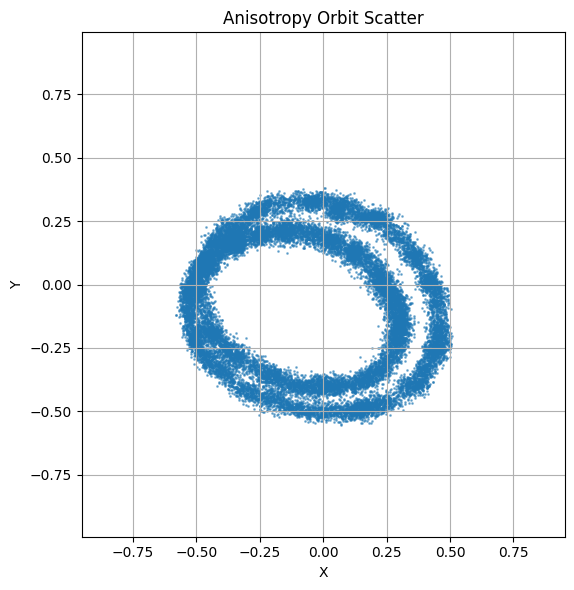

In [3]:
t_start_test = 200.0
t_end_test = 200.1
mask_test = (timestamps >= t_start_test) & (timestamps <= t_end_test)
t_test = timestamps[mask_test]

c0_test   = group["PXI1Slot2/ai3"].data[mask_test]
c45_test  = group["PXI1Slot2/ai1"].data[mask_test]
c90_test  = group["PXI1Slot2/ai0"].data[mask_test]
c135_test = group["PXI1Slot2/ai2"].data[mask_test]

x = (c0_test - c90_test) / (c0_test + c90_test)
y = (c45_test - c135_test) / (c45_test + c135_test)

plt.figure(figsize=(6, 6))
plt.scatter(x, y, s=1, alpha=0.5)
plt.xlabel("X")
plt.ylabel("Y")
plt.title(f"Anisotropy Orbit Scatter")
plt.axis("equal")
plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "anisotropy.png"), dpi=300)
plt.show()

In [4]:
def Fourkas(c0, c90, c45, c135, NA=1.3, nw=1.33):
    alpha = np.arcsin(NA / nw)
    A = 1 / 6 - 1 / 4 * np.cos(alpha) + 1 / 12 * np.cos(alpha) ** 3
    B = 1 / 8 * np.cos(alpha) - 1 / 8 * np.cos(alpha) ** 3
    C = 7 / 48 - np.cos(alpha) / 16 - np.cos(alpha) ** 2 / 16 - np.cos(alpha) ** 3 / 48

    phi = 0.5 * np.arctan2(
        (c45 / 2 - c135 / 2), (c0 / 2 - c90 / 2)
    )

    cs = np.cos(2 * phi)
    ss = np.sin(2 * phi)

    OP = c0 + c45 + c90 + c135
    P = c0 - c90 + c45 - c135

    sinsqtheta = 4 * A * P / (2 * (ss + cs) * OP * C - 4 * B * P)
    test = np.sqrt(np.abs(sinsqtheta))
    test = np.clip(test, 0, 1)
    theta = np.arcsin(test)

    return phi, theta

C:\Users\denny\AppData\Local\Temp\ipykernel_30568\400032675.py:17: RuntimeWarning: invalid value encountered in divide
  sinsqtheta = 4 * A * P / (2 * (ss + cs) * OP * C - 4 * B * P)


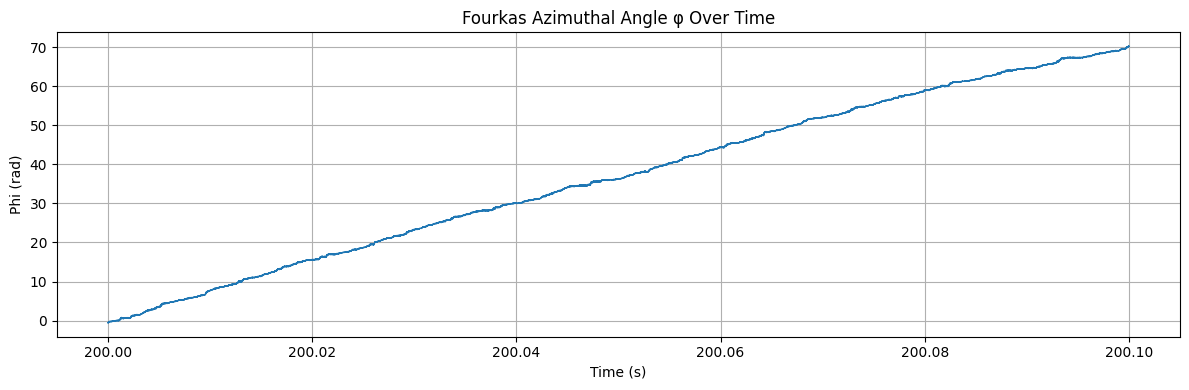

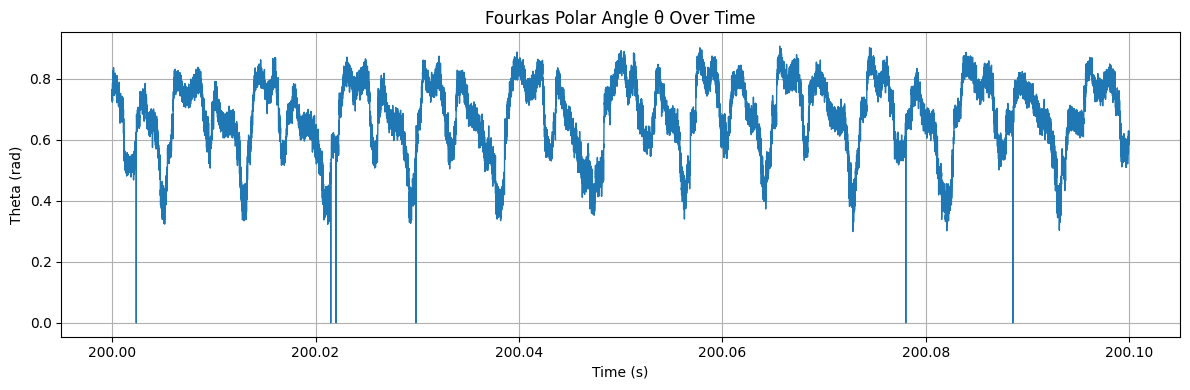

In [5]:
phi_test, theta_test = Fourkas(c0_test, c90_test, c45_test, c135_test)
phi_unwrapped_test = 0.5 * np.unwrap(2 * phi_test)

plt.figure(figsize=(12, 4))
plt.plot(t_test, phi_unwrapped_test, lw=1)
plt.xlabel("Time (s)")
plt.ylabel("Phi (rad)")
plt.title("Fourkas Azimuthal Angle φ Over Time")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "fourkas_phi.png"), dpi=300)
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(t_test, theta_test, lw=1)
plt.xlabel("Time (s)")
plt.ylabel("Theta (rad)")
plt.title("Fourkas Polar Angle θ Over Time")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "fourkas_theta.png"), dpi=300)
plt.show()

In [6]:
# # === Subsample for animation speed
# stride = 50
# x_sub = x[::stride]
# y_sub = y[::stride]
# phi_sub = phi_unwrapped[::stride]
# t_sub = t_masked[::stride]

# # === Setup figure and axes
# fig, axes = plt.subplots(1, 2, figsize=(10, 5))
# ax1, ax2 = axes

# # Left: Anisotropy orbit with background
# ax1.set_title("Anisotropy Orbit")
# ax1.set_xlim(-1, 1)
# ax1.set_ylim(-1, 1)
# ax1.set_aspect('equal')
# ax1.grid(True)
# # Show background full orbit
# ax1.scatter(x, y, s=0.2, alpha=0.1, color='gray', label="Orbit background")
# orbit_dot, = ax1.plot([], [], 'ro', markersize=4)

# # Right: Unit circle with phi marker
# ax2.set_title("Phi Angle on Unit Circle")
# ax2.set_xlim(-1.1, 1.1)
# ax2.set_ylim(-1.1, 1.1)
# ax2.set_aspect('equal')
# ax2.grid(True)
# ax2.add_patch(plt.Circle((0, 0), 1, fill=False, linestyle='--', alpha=0.5))
# phi_dot, = ax2.plot([], [], 'bo', markersize=4)

# def init():
#     orbit_dot.set_data([], [])
#     phi_dot.set_data([], [])
#     return orbit_dot, phi_dot

# def update(i):
#     orbit_dot.set_data(x_sub[i], y_sub[i])
#     phi = phi_sub[i] % (2 * np.pi)
#     phi_dot.set_data(np.cos(phi), np.sin(phi))
#     return orbit_dot, phi_dot

# ani = animation.FuncAnimation(
#     fig, update, frames=len(t_sub),
#     init_func=init, blit=True, interval=50
# )

# gif_path = os.path.join(plot_dir, "anisotropy_vs_phi.gif")
# ani.save(gif_path, writer=PillowWriter(fps=20))
# print(f"Saved GIF to: {gif_path}")

# plt.close()

C:\Users\denny\AppData\Local\Temp\ipykernel_30568\400032675.py:17: RuntimeWarning: invalid value encountered in divide
  sinsqtheta = 4 * A * P / (2 * (ss + cs) * OP * C - 4 * B * P)


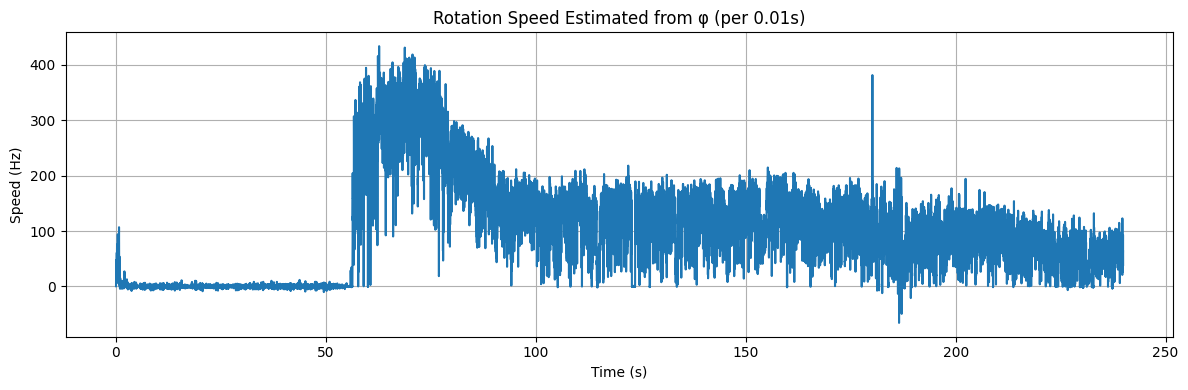

In [7]:
t_start = 0.0
t_end = 239.88
mask = (timestamps >= t_start) & (timestamps <= t_end)
t = timestamps[mask]

c0 = group["PXI1Slot2/ai3"].data[mask]
c45 = group["PXI1Slot2/ai1"].data[mask]
c90 = group["PXI1Slot2/ai0"].data[mask]
c135 = group["PXI1Slot2/ai2"].data[mask]

# === Compute Fourkas φ and unwrap
phi, _ = Fourkas(c0, c90, c45, c135)
phi_unwrapped = 0.5 * np.unwrap(2 * phi)

# # === Save phase data ===
# np.savez_compressed(os.path.join(plot_dir, "fourkas_phase_data_compressed.npz"),
#                     time=t, phi=phi_unwrapped)

# === Compute speed: Δphi / 2π per 0.01 s interval
dt = 0.01
sample_interval = 2500

phi_sliced = phi_unwrapped[::sample_interval]
t_sliced = t[::sample_interval]
dphi = np.diff(phi_sliced)
speed_hz = dphi / (2 * np.pi * dt)
t_speed = t_sliced[1:]  # midpoints

# === Save speed data ===
np.savez(os.path.join(plot_dir, "fourkas_speed_trace.npz"),
         time=t_speed, speed=speed_hz)

# === Plot
plt.figure(figsize=(12, 4))
plt.plot(t_speed, speed_hz, lw=1.5)
plt.xlabel("Time (s)")
plt.ylabel("Speed (Hz)")
plt.title("Rotation Speed Estimated from φ (per 0.01s)")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "fourkas_speed_phi.png"), dpi=300)
plt.show()

In [8]:
# WINDOW_DETECTION = 400
# FIRST_CYCLE_DETECTION_LIMIT = 500_000
# END_OF_CYCLE_LIMIT = 100_000
# DEFAULT_CLOSURE_THRESHOLD = 40

# def detect_and_plot_anisotropy_cycle(x, y, closure_threshold=DEFAULT_CLOSURE_THRESHOLD):
#     """
#     Detect and plot one full cycle in the anisotropy X-Y trajectory.

#     Args:
#         x (np.ndarray): X trajectory = (C0 - C90) / (C0 + C90)
#         y (np.ndarray): Y trajectory = (C45 - C135) / (C45 + C135)
#         closure_threshold (int): Size of the window to assess return overlap

#     Returns:
#         start_idx (int), end_idx (int): Start and end indices of detected cycle
#     """
#     trajectory = np.stack([x, y], axis=1)

#     # Use X axis to identify cycle start candidates
#     main_component = x[:FIRST_CYCLE_DETECTION_LIMIT]
#     amplitude_90 = np.min(main_component) + 0.9 * (np.max(main_component) - np.min(main_component))
#     possible_starts = np.where(main_component > amplitude_90)[0]

#     # Filter to ensure sufficient spacing between starts
#     min_distance = 1000
#     filtered_starts = [possible_starts[0]]
#     for idx in possible_starts[1:]:
#         if idx - filtered_starts[-1] > min_distance:
#             filtered_starts.append(idx)
#         if len(filtered_starts) > 5:
#             break
#     possible_starts = np.array(filtered_starts)

#     # Select best start index based on total squared variation
#     best_start, max_var = possible_starts[0], 0
#     for start in possible_starts:
#         var = np.sum(np.diff(main_component[start:start + END_OF_CYCLE_LIMIT]) ** 2)
#         if var > max_var:
#             max_var = var
#             best_start = start
#     start_idx = best_start

#     # Detect end index based on neighborhood overlap (closure)
#     close_dist = np.median(
#         np.linalg.norm(trajectory[start_idx] - trajectory[start_idx:start_idx + closure_threshold], axis=1)
#     )
#     ref_tree = KDTree(trajectory[start_idx:start_idx + WINDOW_DETECTION])

#     i_list = range(start_idx + 400, start_idx + END_OF_CYCLE_LIMIT, 10)
#     neighbor_counts = []
#     for i in i_list:
#         tree = KDTree(trajectory[i:i + WINDOW_DETECTION])
#         count = tree.count_neighbors(ref_tree, close_dist)
#         neighbor_counts.append(count)

#     # Find strong overlap peaks
#     threshold = 2
#     peaks = []
#     while len(peaks) == 0:
#         peaks = find_peaks(neighbor_counts, prominence=WINDOW_DETECTION / threshold)[0]
#         threshold *= 2
#     _, _, _, right_ips = peak_widths(neighbor_counts, peaks, rel_height=0.5)
#     right_ips = np.round(right_ips).astype(int)

#     # Pick best peak
#     peak_ind = 0
#     while peak_ind < len(peaks) - 1:
#         if np.min(neighbor_counts[:peaks[peak_ind]]) > 2 * np.min(neighbor_counts):
#             peak_ind += 1
#         else:
#             break
#     for k in range(peak_ind, min(peak_ind + 3, len(peaks))):
#         if neighbor_counts[peaks[k]] > 1.5 * neighbor_counts[peaks[peak_ind]]:
#             peak_ind = k

#     end_idx = i_list[right_ips[peak_ind]]

#     # Plot result
#     plt.figure(figsize=(6, 6))
#     plt.plot(x, y, '.', alpha=0.2, label="All")
#     plt.plot(x[start_idx:end_idx], y[start_idx:end_idx], '-', lw=2, label="Detected Cycle")
#     plt.scatter(x[start_idx], y[start_idx], color='green', label='Start', zorder=10)
#     plt.scatter(x[end_idx], y[end_idx], color='red', label='End', zorder=10)
#     plt.xlabel("X = (C0 - C90) / (C0 + C90)")
#     plt.ylabel("Y = (C45 - C135) / (C45 + C135)")
#     plt.title("Detected Cycle on Anisotropy Trajectory")
#     plt.axis("equal")
#     plt.grid(True)
#     plt.legend()
#     plt.tight_layout()
#     plt.show()

#     return start_idx, end_idx
    

In [9]:
# CONVOLUTION_WINDOW = 101
# SMOOTHING = 0.001
# REFERENCE_NUM_POINTS = 200

# def smooth_trajectory(points, smoothing_factor=SMOOTHING, num_points=REFERENCE_NUM_POINTS):
#     """Fit a periodic B-spline to a closed 2D trajectory and return uniformly sampled points."""
#     points = np.array(points)
#     if not np.allclose(points[0], points[-1]):
#         points = np.vstack([points, points[0]])  # enforce closure
#     tck, _ = splprep(points.T, s=smoothing_factor, per=True)
#     u_fine = np.linspace(0, 1, num_points)
#     smoothed = np.array(splev(u_fine, tck)).T
#     return smoothed

# # === Step 1: Savitzky-Golay smoothing of entire trajectory
# xy_raw = np.stack([x, y], axis=1)
# xy_savgol = savgol_filter(xy_raw, window_length=CONVOLUTION_WINDOW, polyorder=3, axis=0)
# x_smooth, y_smooth = xy_savgol[:, 0], xy_savgol[:, 1]

# # === Step 2: Detect cycle on smoothed trajectory
# start_idx, end_idx = detect_and_plot_anisotropy_cycle(x_smooth, y_smooth)
# cycle_segment = xy_savgol[start_idx:end_idx]

# # === Step 3: Final smooth reference cycle from the detected segment
# smooth_ref_cycle = smooth_trajectory(cycle_segment)

# # === Plot the smoothed reference cycle
# plt.figure(figsize=(6, 6))
# plt.plot(x_smooth, y_smooth, '.', alpha=0.2, label="Smoothed Full Trajectory")
# plt.plot(smooth_ref_cycle[:, 0], smooth_ref_cycle[:, 1], 'r-', lw=2, label="Smoothed Reference Cycle")
# plt.axis("equal")
# plt.xlabel("X = (C0 - C90) / (C0 + C90)")
# plt.ylabel("Y = (C45 - C135) / (C45 + C135)")
# plt.title("Final Smoothed Reference Cycle")
# plt.grid(True)
# plt.legend()
# plt.tight_layout()
# plt.show()


In [10]:
# from scipy.spatial.distance import cdist
# from matplotlib.patches import Ellipse
# import matplotlib.pyplot as plt

# def split_by_self_intersection(cycle, threshold=0.02, debug=True):
#     """
#     Split a closed trajectory at its self-intersection (excluding wraparound).

#     Args:
#         cycle (np.ndarray): (N, 2) array of x, y coordinates forming a closed loop.
#         threshold (float): Distance threshold for self-intersection.
#         min_fraction (float): Minimum fractional separation between points (default 0.2).
#         max_fraction (float): Maximum fractional separation between points (default 0.8).
#         debug (bool): Whether to plot the result.

#     Returns:
#         loop1, loop2, (i, j): The two loop segments and the split indices.
#     """
#     N = len(cycle)
#     dists = cdist(cycle, cycle)
#     np.fill_diagonal(dists, np.inf)
#     dists[0, -1] = np.inf
#     dists[-1, 0] = np.inf

#     for i in range(N):
#         dists[i, max(0, i - 50):i + 51] = np.inf

#     min_dist = np.min(dists)
#     i, j = np.unravel_index(np.argmin(dists), dists.shape)

#     if debug:
#         print(f"Min non-neighboring distance: {min_dist:.5f} at indices ({i}, {j})")

#     if i > j:
#         i, j = j, i

#     loop1 = np.vstack([cycle[:i], cycle[j:]])
#     loop2 = cycle[i:j]

#     if debug:
#         plt.figure(figsize=(6,6))
#         plt.plot(cycle[:,0], cycle[:,1], label="Cycle", alpha=0.3)
#         plt.plot(loop1[:,0], loop1[:,1], label="Loop 1", color='orange')
#         plt.plot(loop2[:,0], loop2[:,1], label="Loop 2", color='blue')
#         plt.scatter(*cycle[i], color='red', label='Intersection i')
#         plt.scatter(*cycle[j], color='green', label='Intersection j')
#         plt.legend()
#         plt.axis('equal')
#         plt.title("Split by Self-Intersection (with Fractional Range Constraint)")
#         plt.grid(True)
#         plt.show()

#     return loop1, loop2, (i, j)

# def fit_ellipse_center(points):
#     """
#     Fit a simple ellipse and return its centroid (xc, yc) using least squares.
#     """
#     x, y = points[:, 0], points[:, 1]
#     x_mean, y_mean = np.mean(x), np.mean(y)
#     return x_mean, y_mean

# # === Execute
# loop1, loop2, (i_cross, j_cross) = split_by_self_intersection(smooth_ref_cycle, threshold=0.02, debug=True)

# # Choose inner based on mean radius
# r1 = np.mean(np.linalg.norm(loop1, axis=1))
# r2 = np.mean(np.linalg.norm(loop2, axis=1))
# inner_loop = loop1 if r1 < r2 else loop2
# outer_loop = loop2 if r1 < r2 else loop1

# # Fit ellipse center to inner loop
# xc, yc = fit_ellipse_center(inner_loop)

# # === Plot
# plt.figure(figsize=(6, 6))
# plt.plot(smooth_ref_cycle[:, 0], smooth_ref_cycle[:, 1], color='gray', lw=1, alpha=0.3, label="Ref Cycle")
# plt.plot(inner_loop[:, 0], inner_loop[:, 1], color='orange', lw=2, label="Inner Loop")
# plt.plot(outer_loop[:, 0], outer_loop[:, 1], color='blue', lw=2, alpha=0.4, label="Outer Loop")
# plt.scatter(xc, yc, color='red', marker='x', s=100, label="Inner Center")

# plt.axis("equal")
# plt.grid(True)
# plt.xlabel("X = (C0 - C90) / (C0 + C90)")
# plt.ylabel("Y = (C45 - C135) / (C45 + C135)")
# plt.title("Inner Loop and Fitted Center from Self-Intersection")
# plt.legend()
# plt.tight_layout()
# plt.show()


In [11]:
# # === Step 1: Shift anisotropy center ===
# # Compute original X, Y
# X = (c0 - c90) / (c0 + c90)
# Y = (c45 - c135) / (c45 + c135)

# # Shift using detected inner loop center (xc, yc)
# X_shifted = X - xc
# Y_shifted = Y - yc

# # Optional: plot shifted trajectory
# plt.figure(figsize=(6, 6))
# plt.scatter(X_shifted, Y_shifted, s=1, alpha=0.5)
# plt.xlabel("X (shifted)")
# plt.ylabel("Y (shifted)")
# plt.title("Shifted Anisotropy Trajectory")
# plt.axis("equal")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# # === Step 2: Recalculate φ and θ using Fourkas formula ===
# # Note: we are using the same raw intensity data, just shifting the projection
# phi_shifted, theta_shifted = Fourkas(c0, c90, c45, c135)  # raw signals unchanged
# phi_shifted_unwrapped = 0.5 * np.unwrap(2 * phi_shifted)

# # === Step 3: Plot updated angles ===
# plt.figure(figsize=(12, 4))
# plt.plot(t_masked, phi_shifted_unwrapped, lw=1)
# plt.xlabel("Time (s)")
# plt.ylabel("Unwrapped φ (rad)")
# plt.title("Fourkas φ After Centering Inner Circle")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(12, 4))
# plt.plot(t_masked, theta_shifted, lw=1)
# plt.xlabel("Time (s)")
# plt.ylabel("θ (rad)")
# plt.title("Fourkas θ After Centering Inner Circle")
# plt.grid(True)
# plt.tight_layout()
# plt.show()
